# Document Layout Detection: YOLO vs RT-DETR

## Data Preparation

### Validate Data Extraction

In [1]:
# printing length of folder .data/images/train
import os
num_train_images = len(os.listdir(".data/images/train"))
print(f"Number of training images: {num_train_images}")

Number of training images: 5000


In [2]:
import os
# printing length of folder .data/images/val
num_val_images = len(os.listdir(".data/images/val"))
print(f"Number of validation images: {num_val_images}")

Number of validation images: 944


Prüfe Bild-ID: 3befe907554d779f98556dfc165522b3b6f9adb7c181d015f62e44ed5d482e4b.png (ID: 23333)
Dokumenten-Kategorie: scientific_articles
-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...
-> 9 Bounding Boxen im JSON für dieses Bild gefunden.


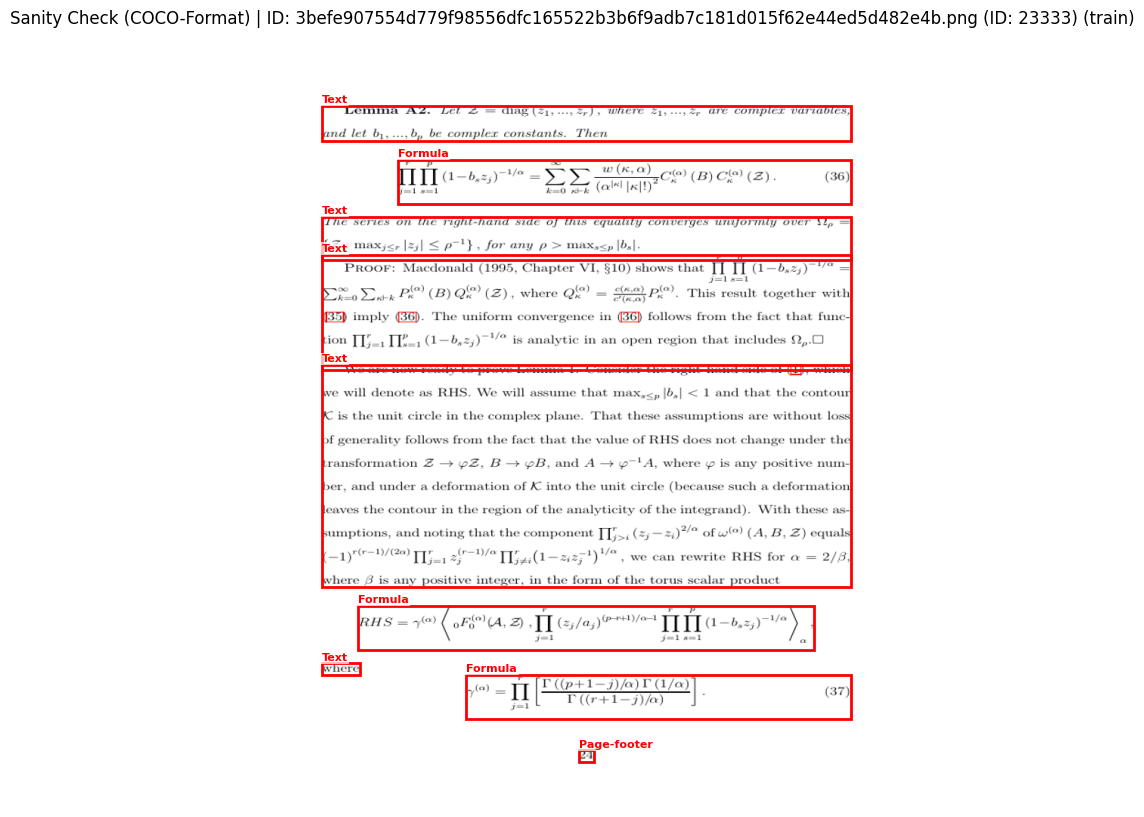

In [23]:
import json
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# PFADE ANPASSEN
SUBSET_DIR = ".data"
SPLIT = "train"  # Welchen Split willst du prüfen? (train, val oder test)

JSON_PATH = f"{SUBSET_DIR}/labels_coco/labels_coco_{SPLIT}.json"
IMAGES_DIR = f"{SUBSET_DIR}/images/{SPLIT}"

# 1. Gekürztes JSON laden
with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# Mappings für die Visualisierung aufbauen
cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}

# Wir wählen ein zufälliges Bild aus den tatsächlich im JSON registrierten Bildern
random_img_info = random.choice(coco_data['images'])
img_file_name = random_img_info['file_name']
img_path = os.path.join(IMAGES_DIR, img_file_name)

print(f"Prüfe Bild-ID: {img_file_name} (ID: {random_img_info['id']})")
print(f"Dokumenten-Kategorie: {random_img_info.get('doc_category')}")

# 2. Prüfen, ob das Bild auch physisch im Ordner existiert
if not os.path.exists(img_path):
    print(f"FEHLER: Bilddatei {img_file_name} wurde nicht im Ordner {IMAGES_DIR} gefunden!")
    exit()
else:
    print("-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...")

# 3. Alle Annotations filtern, die zu dieser Bild-ID gehören
# Fix 1: use 'image_id' (not 'id') and compare against random_img_info['id']
img_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == random_img_info['id']]
print(f"-> {len(img_annotations)} Bounding Boxen im JSON für dieses Bild gefunden.")

# 4. Visuelle Validierung via Matplotlib
img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)

# Jede Box auf das Bild zeichnen
for ann in img_annotations:
    # COCO Format: [x_min, y_min, width, height] (in absoluten Pixeln)
    x, y, w, h = ann['bbox']
    cat_name = cat_id_to_name[ann['category_id']]
    
    # Rechteck zeichnen (Rand rot, transparent innen)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Label-Text über die Box setzen
    plt.text(x, y - 4, cat_name, color='red', fontsize=8, weight='bold', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title(f"Sanity Check (COCO-Format) | ID: {img_file_name} (ID: {random_img_info['id']}) ({SPLIT})")
plt.axis('off')

# Anzeige des Plots
plt.show()

### Convert COCO to YOLO Format

In [13]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir=".data/labels_coco/",
    save_dir=".data/converted",
    cls91to80=False,
)

Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_test.json: 100% ━━━━━━━━━━━━ 943/943 4.2Kit/s 0.2s0.0s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_train.json: 100% ━━━━━━━━━━━━ 4999/4999 4.4Kit/s 1.1s0.0s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_val.json: 100% ━━━━━━━━━━━━ 943/943 5.1Kit/s 0.2s0.2s
COCO data converted successfully.
Results saved to /home/rapha/projects/doclayout-det/.data/converted


In [14]:
import shutil
from pathlib import Path

# Paths
converted_dir = Path(".data/converted/")
dataset_dir = Path(".data")

# Move labels next to images for each split
for split, new_folder_name in [("labels_coco_train", "labels_train"), ("labels_coco_val", "labels_val"), ("labels_coco_test", "labels_test")]:
    src = converted_dir / "labels" / split
    print(src)
    dst = dataset_dir / "labels" / new_folder_name
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob("*.txt"):
        shutil.move(str(f), str(dst / f.name))

# delete the converted directory after moving the labels
if converted_dir.exists():
    shutil.rmtree(converted_dir)

.data/converted/labels/labels_coco_train
.data/converted/labels/labels_coco_val
.data/converted/labels/labels_coco_test


In [15]:
import json
from pathlib import Path

import yaml

# Read categories from your COCO JSON
with open(".data/labels_coco/labels_coco_train.json") as f:
    coco = json.load(f)

# Build class names matching convert_coco output (category_id - 1)
categories = sorted(coco["categories"], key=lambda x: x["id"])
names = {cat["id"] - 1: cat["name"] for cat in categories}
# NOTE: convert_coco maps class IDs as category_id - 1, so category_id must
# start from 1. If your categories start from 0, add 1 to each ID first.

# Create dataset.yaml
dataset = {
    "path": str(Path(".data").resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}

with open(".data/dataset.yaml", "w") as f:
    yaml.dump(dataset, f, default_flow_style=False)

## Training YOLO

In [21]:
from ultralytics import YOLO

# Lade das Modell
model = YOLO("yolo26n.pt")

# Starte das Training mit strikten Ressourcen-Limits
results = model.train(
    data=".data/dataset.yaml", 
    epochs=10, 
    imgsz=640,
    batch=16,          # Sehr niedrig anfangen (Standard ist 16). Wenn es läuft, kannst du auf 8 hochgehen.
    workers=1,        # CRITICAL FÜR WSL: Nur 1 CPU-Thread zum Datenladen nutzen. Verhindert den RAM-Crash!
    amp=True,         # Aktiviert Mixed Precision (schont VRAM massiv)
    cache=False,      # CRITICAL FÜR RAM: Bilder NICHT komplett in den RAM laden, sondern von der SSD streamen
    device=0          # Erzwingt die Nutzung der Nvidia-GPU (falls du mehrere GPUs hast, sonst weglassen)
)

Ultralytics 8.4.56 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [24]:
print("\n--- TESTRUN EVALUATION METRICS ---")
print(f"mAP50:    {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")


--- TESTRUN EVALUATION METRICS ---
mAP50:    0.7619
mAP50-95: 0.6102


## Training RT-DETR

In [1]:
from ultralytics import RTDETR

# Lade das vortrainierte RT-DETR-Large Modell
model = RTDETR("rtdetr-l.pt")

# Starte das kontrollierte Vergleichstraining
results = model.train(
    data="my_dataset/dataset.yaml", 
    epochs=10,         # Exakt wie bei deinem YOLO-Lauf für den fairen Vergleich!
    imgsz=640,         # Dieselbe Auflösung
    batch=2,           # CRITICAL: Sehr niedrig ansetzen wegen VRAM!
    workers=1,         # Schont den WSL-RAM
    cache=False,
    amp=True           # Pflicht für 6GB VRAM
)

Ultralytics 8.4.56 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=my_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

RuntimeError: Dataset 'my_dataset/dataset.yaml' error ❌ 'my_dataset/dataset.yaml' does not exist

## Evaluation

In [ ]:
from ultralytics import YOLO, RTDETR
import os

# PFADE ANPASSEN - Nutze die Pfade zu deinen besten Gewichten (.pt)
# Ultralytics speichert diese automatisch unter 'runs/detect/train/weights/best.pt'
YOLO_WEIGHTS = "runs/detect/train/weights/best.pt"
RTDETR_WEIGHTS = "runs/detect/train_rtdetr/weights/best.pt" # Falls du RT-DETR schon trainiert hast

def evaluate_model(model_path, model_type="YOLO"):
    print(f"\n==================================================")
    print(f" Starte Evaluation für {model_type} ({model_path})")
    print(f"==================================================")
    
    if not os.path.exists(model_path):
        print(f"Fehler: Gewichte unter {model_path} nicht gefunden!")
        return
    
    # 1. Modell laden
    if model_type == "YOLO":
        model = YOLO(model_path)
    elif model_type == "RT-DETR":
        model = RTDETR(model_path)
        
    # 2. Evaluation auf dem TEST-Split ausführen
    # Wir nutzen den Test-Split, da dieser im Training komplett unangetastet blieb!
    metrics = model.val(
        data="my_dataset/dataset.yaml", 
        split="test",        # Wichtig: Explizit auf 'test' evaluieren, nicht auf 'val'
        imgsz=640,
        batch=4,             # VRAM-Schonung
        workers=1,           # WSL-Stabilität
        device=0
    )
    
    # 3. Die wichtigsten Metriken für die Prüfungsauswertung drucken
    print(f"\n--- Finale Ergebnisse für {model_type} ---")
    print(f"mAP@50 (Hauptmetrik für Dokumentenlayout): {metrics.box.map50:.4f}")
    print(f"mAP@50-95 (Strengere Metrik für Box-Präzision): {metrics.box.map:.4f}")
    print(f"Precision (Wie viele gefundene Boxen waren korrekt?): {metrics.box.mp:.4f}")
    print(f"Recall (Wie viele der echten Boxen wurden gefunden?): {metrics.box.mr:.4f}")
    
    # Geschwindigkeit (Inference Speed) ausgeben - Extrem wichtig für den RT-DETR vs YOLO Vergleich!
    # Zeiten sind in Millisekunden pro Bild angegeben
    print(f"\n--- Geschwindigkeits-Metriken (pro Bild in ms) ---")
    print(f"Pre-process: {metrics.speed['preprocess']:.2f} ms")
    print(f"Inference (Reine Modell-Rechnungszeit): {metrics.speed['inference']:.2f} ms")
    print(f"Post-process (z.B. NMS bei YOLO): {metrics.speed['postprocess']:.2f} ms")

# Ausführen der Evaluation
if __name__ == "__main__":
    # Evaluiere dein trainiertes YOLO
    evaluate_model(YOLO_WEIGHTS, model_type="YOLO")
    
    # Sobald dein RT-DETR fertig ist, einfach einkommentieren:
    # evaluate_model(RTDETR_WEIGHTS, model_type="RT-DETR")